# 05 - Missing Values and Outlier Check

Notebook nay thuc hien:
1. Quet missing values toan bo 14 file CSV
2. Phat hien outlier tren cac cot so (IQR + Z-score)
3. Kiem tra logic: date, negative values, duplicates
4. Tong hop ket qua vao bang de quyet dinh xu ly o buoc sau

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

DATA_DIR   = Path('../data')
REPORT_DIR = Path('../reports/charts/quality')
REPORT_DIR.mkdir(parents=True, exist_ok=True)

NULL_WARN_PCT = 5.0
IQR_FACTOR    = 1.5
ZSCORE_THRESH = 3.0

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

TABLE_ORDER = [
    'orders', 'order_items', 'products', 'customers',
    'payments', 'shipments', 'returns', 'reviews',
    'promotions', 'geography', 'inventory', 'web_traffic', 'sales',
]

def load_table(name):
    path = DATA_DIR / f'{name}.csv'
    df = pd.read_csv(path, low_memory=False)
    print(f'  {name:15s}: {df.shape[0]:>7,} rows  x  {df.shape[1]:>2} cols')
    return df

print('Loading tables...')
TABLES = {name: load_table(name) for name in TABLE_ORDER}
print(f'Loaded {len(TABLES)} tables.')

Loading tables...
  orders         : 646,945 rows  x   8 cols
  order_items    : 714,669 rows  x   7 cols
  products       :   2,412 rows  x   8 cols
  customers      : 121,930 rows  x   7 cols
  payments       : 646,945 rows  x   4 cols
  shipments      : 566,067 rows  x   4 cols
  returns        :  39,939 rows  x   7 cols
  reviews        : 113,551 rows  x   7 cols
  promotions     :      50 rows  x  10 cols
  geography      :  39,948 rows  x   4 cols
  inventory      :  60,247 rows  x  17 cols
  web_traffic    :   3,652 rows  x   7 cols
  sales          :   3,833 rows  x   3 cols
Loaded 13 tables.


## 1. Missing Values - Scan toan bo

In [2]:
def missing_summary(name, df):
    total      = len(df)
    null_count = df.isnull().sum()
    null_pct   = null_count / total * 100
    return pd.DataFrame({
        'table'     : name,
        'column'    : null_count.index,
        'dtype'     : [str(df[c].dtype) for c in null_count.index],
        'null_count': null_count.values,
        'null_pct'  : null_pct.values.round(2),
    }).reset_index(drop=True)

all_missing = pd.concat(
    [missing_summary(name, df) for name, df in TABLES.items()],
    ignore_index=True
)
has_null = all_missing[all_missing['null_count'] > 0].copy()

print(f'Tong so columns : {len(all_missing)}')
print(f'Columns co null  : {len(has_null)}')
print(f'Columns sach    : {len(all_missing) - len(has_null)}')

def highlight_warn(val):
    if isinstance(val, (int, float)) and val >= NULL_WARN_PCT:
        return 'background-color: #ffe0e0; font-weight: bold'
    return ''

display(
    has_null.style
    .applymap(highlight_warn, subset=['null_pct'])
    .format({'null_pct': '{:.2f}%'})
    .set_caption(f'Missing Values (highlight >= {NULL_WARN_PCT}%)')
    .hide(axis='index')
)

Tong so columns : 93
Columns co null  : 3
Columns sach    : 90


table,column,dtype,null_count,null_pct
order_items,promo_id,object,438353,61.34%
order_items,promo_id_2,object,714463,99.97%
promotions,applicable_category,object,40,80.00%


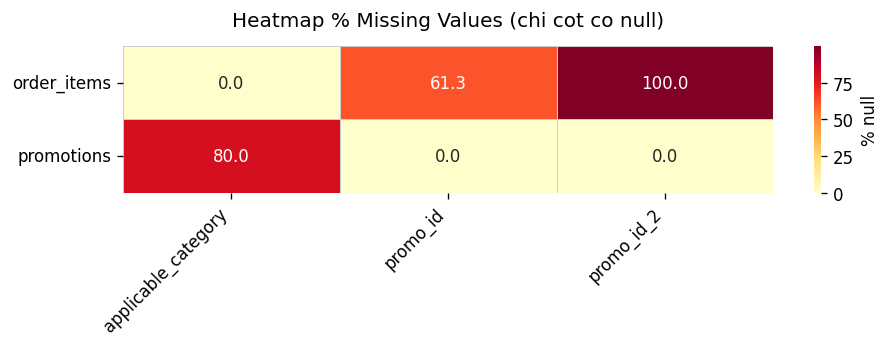

In [3]:
if len(has_null) > 0:
    pivot = has_null.pivot_table(
        index='table', columns='column', values='null_pct', aggfunc='first'
    ).fillna(0)
    fig_h = max(3, len(pivot) * 0.5)
    fig_w = max(8, len(pivot.columns) * 0.7)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
                linewidths=0.5, linecolor='#cccccc',
                cbar_kws={'label': '% null'}, ax=ax)
    ax.set_title('Heatmap % Missing Values (chi cot co null)', fontsize=12, pad=12)
    ax.set_xlabel('')
    ax.set_ylabel('')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(REPORT_DIR / 'missing_heatmap.png', bbox_inches='tight')
    plt.show()
else:
    print('Khong co missing values.')

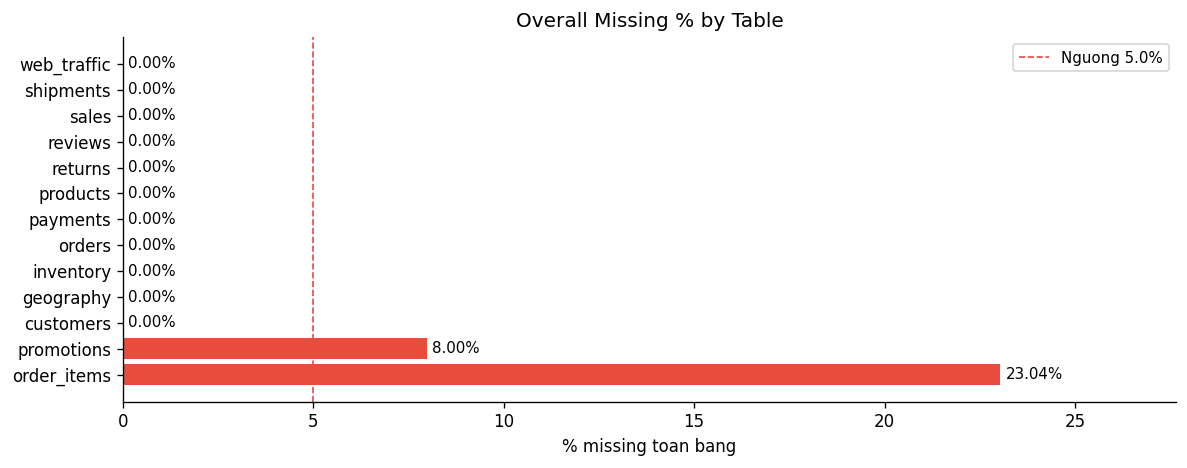

In [4]:
table_null = (
    all_missing.groupby('table')
    .apply(lambda g: g['null_count'].sum() / (len(TABLES[g['table'].iloc[0]]) * len(g)) * 100)
    .reset_index()
)
table_null.columns = ['table', 'overall_null_pct']
table_null = table_null.sort_values('overall_null_pct', ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#e74c3c' if v >= NULL_WARN_PCT else '#3498db'
          for v in table_null['overall_null_pct']]
bars = ax.barh(table_null['table'], table_null['overall_null_pct'], color=colors)
ax.axvline(NULL_WARN_PCT, color='#e74c3c', linestyle='--', linewidth=1,
           label=f'Nguong {NULL_WARN_PCT}%')
ax.bar_label(bars, fmt='%.2f%%', padding=3, fontsize=9)
ax.set_xlabel('% missing toan bang')
ax.set_title('Overall Missing % by Table')
ax.legend(fontsize=9)
ax.set_xlim(0, max(table_null['overall_null_pct'].max() * 1.2, NULL_WARN_PCT * 2))
plt.tight_layout()
plt.savefig(REPORT_DIR / 'missing_by_table.png', bbox_inches='tight')
plt.show()

## 2. Missing Values - Chi tiet tung bang

In [5]:
for name, df in TABLES.items():
    ms = missing_summary(name, df)
    ms_nonzero = ms[ms['null_count'] > 0]
    if ms_nonzero.empty:
        print(f'[{name}] -> Khong co missing values')
    else:
        print(f'\n[{name}] - {len(df):,} rows')
        display(
            ms_nonzero.style
            .applymap(highlight_warn, subset=['null_pct'])
            .format({'null_pct': '{:.2f}%'})
            .hide(axis='index')
        )

[orders] -> Khong co missing values

[order_items] - 714,669 rows


table,column,dtype,null_count,null_pct
order_items,promo_id,object,438353,61.34%
order_items,promo_id_2,object,714463,99.97%


[products] -> Khong co missing values
[customers] -> Khong co missing values
[payments] -> Khong co missing values
[shipments] -> Khong co missing values
[returns] -> Khong co missing values
[reviews] -> Khong co missing values

[promotions] - 50 rows


table,column,dtype,null_count,null_pct
promotions,applicable_category,object,40,80.00%


[geography] -> Khong co missing values
[inventory] -> Khong co missing values
[web_traffic] -> Khong co missing values
[sales] -> Khong co missing values


## 3. Outlier Detection - IQR + Z-score

In [6]:
def outlier_summary(name, df):
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    records = []
    for col in num_cols:
        s = df[col].dropna()
        if len(s) < 10:
            continue
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr    = q3 - q1
        lo_iqr = q1 - IQR_FACTOR * iqr
        hi_iqr = q3 + IQR_FACTOR * iqr
        n_iqr  = int(((s < lo_iqr) | (s > hi_iqr)).sum())
        z      = np.abs(stats.zscore(s, nan_policy='omit'))
        n_z    = int((z > ZSCORE_THRESH).sum())
        records.append({
            'table'          : name,
            'column'         : col,
            'n_valid'        : len(s),
            'min'            : round(float(s.min()), 4),
            'max'            : round(float(s.max()), 4),
            'mean'           : round(float(s.mean()), 4),
            'median'         : round(float(s.median()), 4),
            'std'            : round(float(s.std()), 4),
            'q1'             : round(float(q1), 4),
            'q3'             : round(float(q3), 4),
            'iqr_lo'         : round(float(lo_iqr), 4),
            'iqr_hi'         : round(float(hi_iqr), 4),
            'n_outlier_iqr'  : n_iqr,
            'pct_outlier_iqr': round(n_iqr / len(s) * 100, 2),
            'n_outlier_z'    : n_z,
            'pct_outlier_z'  : round(n_z / len(s) * 100, 2),
        })
    return pd.DataFrame(records)

all_outlier = pd.concat(
    [outlier_summary(name, df) for name, df in TABLES.items()],
    ignore_index=True
)

print(f'Tong so numerical columns duoc kiem tra : {len(all_outlier)}')
print(f'Columns co outlier (IQR) : {(all_outlier["n_outlier_iqr"] > 0).sum()}')
print(f'Columns co outlier (Z)   : {(all_outlier["n_outlier_z"] > 0).sum()}')

Tong so numerical columns duoc kiem tra : 50
Columns co outlier (IQR) : 20
Columns co outlier (Z)   : 17


In [7]:
display_cols = [
    'table', 'column', 'n_valid', 'min', 'max', 'mean', 'median', 'std',
    'iqr_lo', 'iqr_hi', 'n_outlier_iqr', 'pct_outlier_iqr',
    'n_outlier_z', 'pct_outlier_z',
]

def highlight_outlier(val):
    if isinstance(val, (int, float)) and val >= 5.0:
        return 'background-color: #ffe0e0; font-weight: bold'
    elif isinstance(val, (int, float)) and val >= 1.0:
        return 'background-color: #fff3cd'
    return ''

display(
    all_outlier[display_cols]
    .sort_values('pct_outlier_iqr', ascending=False)
    .style
    .applymap(highlight_outlier, subset=['pct_outlier_iqr', 'pct_outlier_z'])
    .format({
        'pct_outlier_iqr': '{:.2f}%', 'pct_outlier_z': '{:.2f}%',
        'min': '{:.3f}', 'max': '{:.3f}',
        'mean': '{:.3f}', 'median': '{:.3f}', 'std': '{:.3f}',
    })
    .set_caption('Outlier Summary (IQR x1.5 + Z-score >3)')
    .hide(axis='index')
)

table,column,n_valid,min,max,mean,median,std,iqr_lo,iqr_hi,n_outlier_iqr,pct_outlier_iqr,n_outlier_z,pct_outlier_z
promotions,stackable_flag,50,0.000,1.000,0.240,0.000,0.431,0.000000,0.000000,12,24.00%,0,0.00%
inventory,overstock_flag,60247,0.000,1.000,0.763,1.000,0.425,1.000000,1.000000,14305,23.74%,0,0.00%
order_items,discount_amount,714669,0.000,35235.470,1048.887,0.000,2280.531,-1451.445000,2419.075000,105767,14.80%,19160,2.68%
shipments,shipping_fee,566067,0.000,32.000,4.963,1.730,8.887,-1.725000,5.195000,76050,13.43%,2951,0.52%
inventory,days_of_supply,60247,5.200,68100.000,912.678,240.000,2587.624,-784.650000,1563.750000,7455,12.37%,942,1.56%
inventory,stock_on_hand,60247,3.000,2673.000,189.298,62.000,316.976,-277.500000,502.500000,6432,10.68%,1613,2.68%
inventory,units_received,60247,1.000,817.000,18.047,6.000,34.080,-23.500000,44.500000,6392,10.61%,1213,2.01%
inventory,units_sold,60247,1.000,670.000,15.418,6.000,28.404,-19.000000,37.000000,6388,10.60%,1239,2.06%
promotions,discount_value,50,10.000,50.000,18.500,16.500,11.242,0.000000,32.000000,5,10.00%,0,0.00%
returns,refund_amount,39939,458.810,160937.940,12784.459,7888.880,14092.150,-16389.497500,36844.882500,2778,6.96%,904,2.26%


## 4. Boxplot - Cac cot so co outlier cao nhat

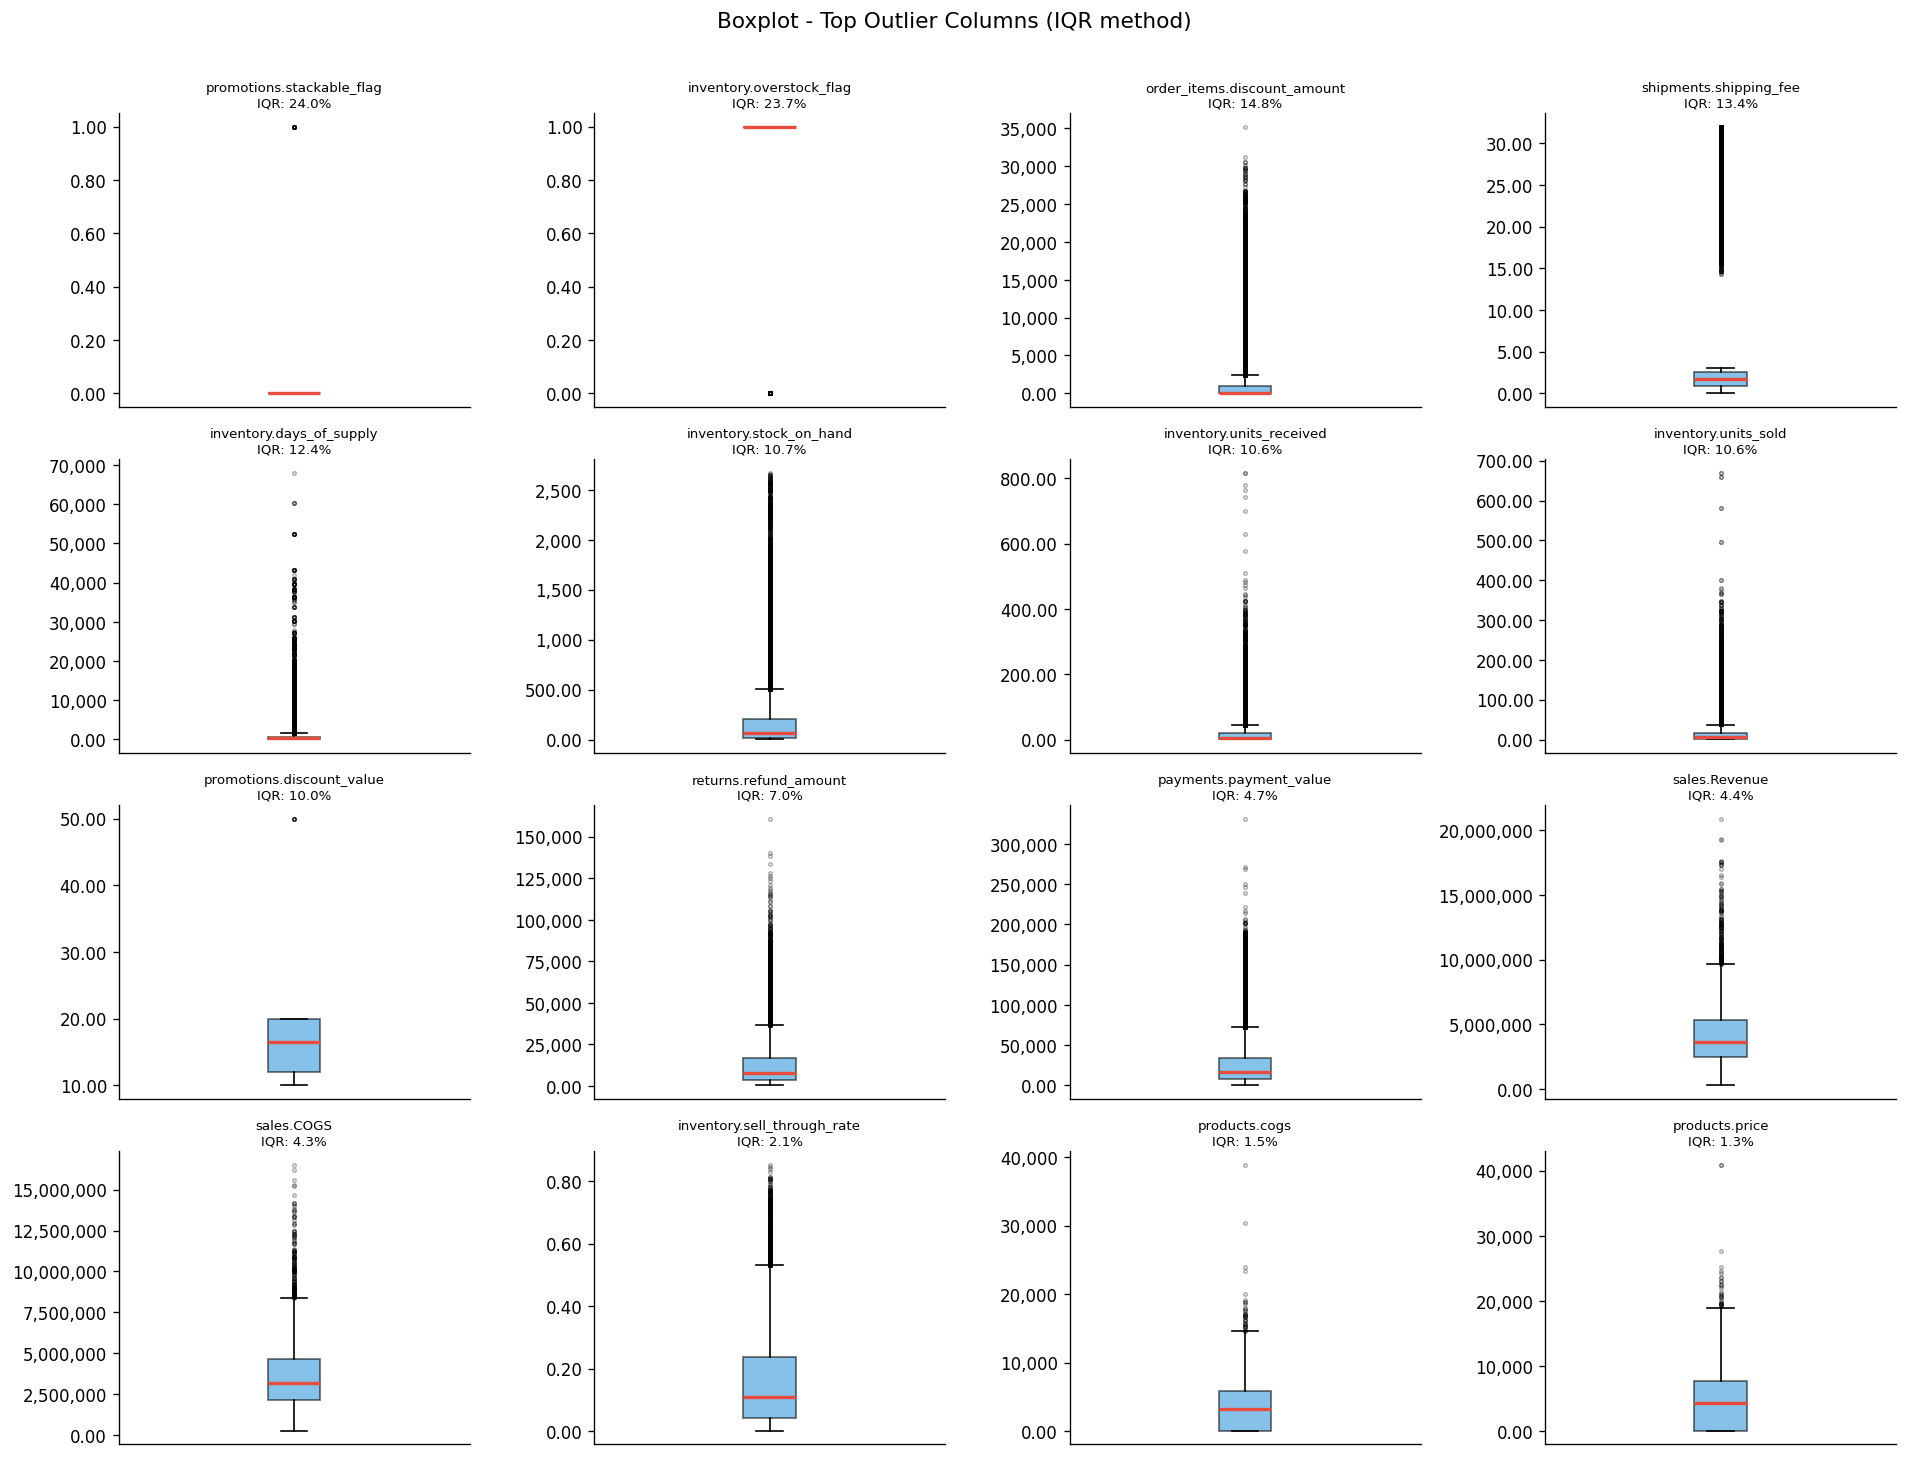

In [8]:
top_outlier = (
    all_outlier[all_outlier['n_outlier_iqr'] > 0]
    .sort_values('pct_outlier_iqr', ascending=False)
    .head(16)
)

n = len(top_outlier)
if n == 0:
    print('Khong co outlier.')
else:
    ncols = 4
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
    axes = np.array(axes).flatten()
    for i, (_, row) in enumerate(top_outlier.iterrows()):
        ax = axes[i]
        s = TABLES[row['table']][row['column']].dropna()
        ax.boxplot(s, vert=True, patch_artist=True,
                   boxprops=dict(facecolor='#3498db', alpha=0.6),
                   medianprops=dict(color='#e74c3c', linewidth=2),
                   flierprops=dict(marker='o', markersize=2, alpha=0.3, color='#e74c3c'))
        ax.set_title(
            f"{row['table']}.{row['column']}\nIQR: {row['pct_outlier_iqr']:.1f}%",
            fontsize=8, pad=4)
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f'{x:,.0f}' if abs(x) >= 1000 else f'{x:.2f}')
        )
        ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Boxplot - Top Outlier Columns (IQR method)', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(REPORT_DIR / 'outlier_boxplots.png', bbox_inches='tight')
    plt.show()

## 5. Chi tiet outlier - tung bang

In [9]:
for name, df in TABLES.items():
    sub = all_outlier[
        (all_outlier['table'] == name) & (all_outlier['n_outlier_iqr'] > 0)
    ]
    if sub.empty:
        print(f'[{name}] -> Khong co outlier (IQR)')
        continue
    print(f'\n[{name}] - {len(df):,} rows')
    display(
        sub[display_cols].style
        .applymap(highlight_outlier, subset=['pct_outlier_iqr', 'pct_outlier_z'])
        .format({'pct_outlier_iqr': '{:.2f}%', 'pct_outlier_z': '{:.2f}%'})
        .hide(axis='index')
    )

[orders] -> Khong co outlier (IQR)

[order_items] - 714,669 rows


table,column,n_valid,min,max,mean,median,std,iqr_lo,iqr_hi,n_outlier_iqr,pct_outlier_iqr,n_outlier_z,pct_outlier_z
order_items,unit_price,714669,392.570000,43056.000000,5114.690200,4257.770000,3774.817900,-6143.415000,15324.065000,8623,1.21%,5766,0.81%
order_items,discount_amount,714669,0.000000,35235.470000,1048.887400,0.000000,2280.530600,-1451.445000,2419.075000,105767,14.80%,19160,2.68%



[products] - 2,412 rows


table,column,n_valid,min,max,mean,median,std,iqr_lo,iqr_hi,n_outlier_iqr,pct_outlier_iqr,n_outlier_z,pct_outlier_z
products,price,2412,9.056600,40950.000000,4928.216200,4399.605000,4776.737700,-11432.158400,19212.117100,31,1.29%,30,1.24%
products,cogs,2412,5.183800,38902.500000,3868.346700,3184.934100,3878.584200,-8709.708800,14609.691600,37,1.53%,29,1.20%


[customers] -> Khong co outlier (IQR)

[payments] - 646,945 rows


...

table,column,n_valid,min,max,mean,median,std,iqr_lo,iqr_hi,n_outlier_iqr,pct_outlier_iqr,n_outlier_z,pct_outlier_z
inventory,stock_on_hand,60247,3.000000,2673.000000,189.298500,62.000000,316.976100,-277.500000,502.500000,6432,10.68%,1613,2.68%
inventory,units_received,60247,1.000000,817.000000,18.046800,6.000000,34.080200,-23.500000,44.500000,6392,10.61%,1213,2.01%
inventory,units_sold,60247,1.000000,670.000000,15.417800,6.000000,28.404400,-19.000000,37.000000,6388,10.60%,1239,2.06%
inventory,stockout_days,60247,0.000000,28.000000,1.160600,1.000000,1.624500,-3.000000,5.000000,724,1.20%,624,1.04%
inventory,days_of_supply,60247,5.200000,68100.000000,912.677600,240.000000,2587.624100,-784.650000,1563.750000,7455,12.37%,942,1.56%
inventory,fill_rate,60247,0.066700,1.000000,0.961300,0.966700,0.054200,0.833300,1.100000,724,1.20%,624,1.04%
inventory,overstock_flag,60247,0.000000,1.000000,0.762600,1.000000,0.425500,1.000000,1.000000,14305,23.74%,0,0.00%
inventory,sell_through_rate,60247,0.000400,0.853100,0.152300,0.111100,0.139300,-0.251900,0.532100,1284,2.13%,934,1.55%



[web_traffic] - 3,652 rows


table,column,n_valid,min,max,mean,median,std,iqr_lo,iqr_hi,n_outlier_iqr,pct_outlier_iqr,n_outlier_z,pct_outlier_z
web_traffic,page_views,3652,30451.000000,275560.000000,108615.224500,101010.500000,44472.055500,-24674.000000,235742.000000,18,0.49%,10,0.27%



[sales] - 3,833 rows


table,column,n_valid,min,max,mean,median,std,iqr_lo,iqr_hi,n_outlier_iqr,pct_outlier_iqr,n_outlier_z,pct_outlier_z
sales,Revenue,3833,279813.940000,20905271.350000,4286584.029600,3647303.900000,2624840.198200,-1848593.750000,9670559.770000,169,4.41%,75,1.96%
sales,COGS,3833,236576.310000,16535857.670000,3695134.495000,3161112.990000,2219788.768600,-1579490.305000,8367364.455000,165,4.30%,72,1.88%


## 6. Kiem tra dac biet - Gia tri am bat thuong

In [10]:
POSITIVE_CHECKS = {
    'order_items': ['quantity', 'unit_price', 'discount_amount'],
    'products'   : ['price', 'cogs'],
    'payments'   : ['payment_value', 'installments'],
    'shipments'  : ['shipping_fee'],
    'returns'    : ['return_quantity', 'refund_amount'],
    'inventory'  : ['stock_on_hand', 'units_received', 'units_sold',
                     'stockout_days', 'days_of_supply', 'fill_rate', 'sell_through_rate'],
    'web_traffic': ['sessions', 'unique_visitors', 'page_views',
                     'bounce_rate', 'avg_session_duration_sec'],
    'sales'      : ['Revenue', 'COGS'],
}

neg_records = []
for tbl, cols in POSITIVE_CHECKS.items():
    df = TABLES[tbl]
    for col in cols:
        if col not in df.columns:
            continue
        n_neg  = int((df[col] < 0).sum())
        n_zero = int((df[col] == 0).sum())
        if n_neg > 0 or n_zero > 0:
            neg_records.append({
                'table': tbl, 'column': col,
                'n_negative' : n_neg,
                'pct_negative': round(n_neg  / len(df) * 100, 3),
                'n_zero'     : n_zero,
                'pct_zero'   : round(n_zero / len(df) * 100, 3),
            })

if neg_records:
    neg_df = pd.DataFrame(neg_records)
    print('Gia tri am hoac zero trong cac cot phai duong:')
    display(
        neg_df.style
        .applymap(
            lambda v: 'background-color:#ffe0e0;font-weight:bold'
            if isinstance(v, (int, float)) and v > 0 else '',
            subset=['n_negative']
        )
        .format({'pct_negative': '{:.3f}%', 'pct_zero': '{:.3f}%'})
        .hide(axis='index')
    )
else:
    print('Tat ca cac cot phai duong deu hop le (>= 0).')

Gia tri am hoac zero trong cac cot phai duong:


table,column,n_negative,pct_negative,n_zero,pct_zero
order_items,discount_amount,0,0.000%,438353,61.337%
shipments,shipping_fee,0,0.000%,805,0.142%
inventory,stockout_days,0,0.000%,19676,32.659%


## 7. Kiem tra dac biet - Date range va logic

In [11]:
DATE_COLS = {
    'orders'     : ['order_date'],
    'customers'  : ['signup_date'],
    'shipments'  : ['ship_date', 'delivery_date'],
    'returns'    : ['return_date'],
    'reviews'    : ['review_date'],
    'inventory'  : ['snapshot_date'],
    'web_traffic': ['date'],
    'sales'      : ['Date'],
    'promotions' : ['start_date', 'end_date'],
}

print('=== Date range check ===')
for tbl, cols in DATE_COLS.items():
    df = TABLES[tbl].copy()
    print(f'\n[{tbl}]')
    for col in cols:
        if col not in df.columns:
            continue
        try:
            parsed = pd.to_datetime(df[col], errors='coerce')
            n_fail = parsed.isnull().sum() - df[col].isnull().sum()
            print(f'  {col}: min={parsed.min().date()}  max={parsed.max().date()}  parse_fail={n_fail}')
        except Exception as ex:
            print(f'  {col}: ERROR - {ex}')

=== Date range check ===

[orders]
  order_date: min=2012-07-04  max=2022-12-31  parse_fail=0

[customers]
  signup_date: min=2012-01-17  max=2022-12-31  parse_fail=0

[shipments]
  ship_date: min=2012-07-04  max=2022-12-29  parse_fail=0
  delivery_date: min=2012-07-06  max=2022-12-31  parse_fail=0

[returns]
  return_date: min=2012-07-11  max=2022-12-31  parse_fail=0

[reviews]
  review_date: min=2012-07-10  max=2022-12-31  parse_fail=0

[inventory]
  snapshot_date: min=2012-07-31  max=2022-12-31  parse_fail=0

[web_traffic]
  date: min=2013-01-01  max=2022-12-31  parse_fail=0

[sales]
  Date: min=2012-07-04  max=2022-12-31  parse_fail=0

[promotions]
  start_date: min=2013-01-31  max=2022-11-18  parse_fail=0
  end_date: min=2013-03-01  max=2022-12-31  parse_fail=0


In [12]:
orders_df    = TABLES['orders'].copy()
shipments_df = TABLES['shipments'].copy()
orders_df['order_date']       = pd.to_datetime(orders_df['order_date'],       errors='coerce')
shipments_df['ship_date']     = pd.to_datetime(shipments_df['ship_date'],     errors='coerce')
shipments_df['delivery_date'] = pd.to_datetime(shipments_df['delivery_date'], errors='coerce')

merged_ship = shipments_df.merge(orders_df[['order_id', 'order_date']], on='order_id', how='left')
n_ship_before_order = int((merged_ship['ship_date']     < merged_ship['order_date']).sum())
n_del_before_ship   = int((merged_ship['delivery_date'] < merged_ship['ship_date']).sum())
n_del_before_order  = int((merged_ship['delivery_date'] < merged_ship['order_date']).sum())

print('Logic check - shipments vs orders:')
print(f'  ship_date < order_date    : {n_ship_before_order:,} rows')
print(f'  delivery_date < ship_date : {n_del_before_ship:,} rows')
print(f'  delivery_date < order_date: {n_del_before_order:,} rows')

promo = TABLES['promotions'].copy()
promo['start_date'] = pd.to_datetime(promo['start_date'], errors='coerce')
promo['end_date']   = pd.to_datetime(promo['end_date'],   errors='coerce')
n_bad_promo = int((promo['end_date'] < promo['start_date']).sum())
print(f'\npromotions: end_date < start_date -> {n_bad_promo} rows')

returns_df = TABLES['returns'].copy()
returns_df['return_date'] = pd.to_datetime(returns_df['return_date'], errors='coerce')
merged_ret = returns_df.merge(orders_df[['order_id', 'order_date']], on='order_id', how='left')
n_ret_before_order = int((merged_ret['return_date'] < merged_ret['order_date']).sum())
print(f'returns: return_date < order_date -> {n_ret_before_order} rows')

Logic check - shipments vs orders:
  ship_date < order_date    : 0 rows
  delivery_date < ship_date : 0 rows
  delivery_date < order_date: 0 rows

promotions: end_date < start_date -> 0 rows
returns: return_date < order_date -> 0 rows


## 8. Kiem tra duplicate rows

In [13]:
PK_COLS = {
    'orders'     : ['order_id'],
    'order_items': ['order_id', 'product_id'],
    'products'   : ['product_id'],
    'customers'  : ['customer_id'],
    'payments'   : ['order_id'],
    'shipments'  : ['order_id'],
    'returns'    : ['return_id'],
    'reviews'    : ['review_id'],
    'promotions' : ['promo_id'],
    'geography'  : ['zip'],
    'sales'      : ['Date'],
}

dup_records = []
for tbl, pk in PK_COLS.items():
    df = TABLES[tbl]
    existing_pk = [c for c in pk if c in df.columns]
    if not existing_pk:
        continue
    n_dup = int(df.duplicated(subset=existing_pk, keep=False).sum())
    dup_records.append({
        'table': tbl, 'pk_cols': str(existing_pk),
        'n_total': len(df), 'n_duplicate': n_dup,
        'pct_dup': round(n_dup / len(df) * 100, 3)
    })

dup_df = pd.DataFrame(dup_records)
display(
    dup_df.style
    .applymap(
        lambda v: 'background-color:#ffe0e0;font-weight:bold'
        if isinstance(v, (int, float)) and v > 0 else '',
        subset=['n_duplicate']
    )
    .format({'pct_dup': '{:.3f}%'})
    .set_caption('Duplicate check theo Primary Key')
    .hide(axis='index')
)

table,pk_cols,n_total,n_duplicate,pct_dup
orders,['order_id'],646945,0,0.000%
order_items,"['order_id', 'product_id']",714669,32,0.004%
products,['product_id'],2412,0,0.000%
customers,['customer_id'],121930,0,0.000%
payments,['order_id'],646945,0,0.000%
shipments,['order_id'],566067,0,0.000%
returns,['return_id'],39939,0,0.000%
reviews,['review_id'],113551,0,0.000%
promotions,['promo_id'],50,0,0.000%
geography,['zip'],39948,0,0.000%


## 9. Tong hop - Data Quality Summary

In [14]:
summary_records = []
for name, df in TABLES.items():
    ms  = missing_summary(name, df)
    out = all_outlier[all_outlier['table'] == name]
    dup_row = dup_df[dup_df['table'] == name] if name in dup_df['table'].values else None

    total_cells   = df.shape[0] * df.shape[1]
    total_null    = ms['null_count'].sum()
    max_null_pct  = ms['null_pct'].max() if len(ms) > 0 else 0
    total_out_iqr = out['n_outlier_iqr'].sum() if len(out) > 0 else 0
    n_dup = dup_row['n_duplicate'].values[0] if dup_row is not None and len(dup_row) > 0 else 0

    summary_records.append({
        'table'           : name,
        'rows'            : df.shape[0],
        'cols'            : df.shape[1],
        'total_null'      : int(total_null),
        'null_pct_overall': round(total_null / total_cells * 100, 2),
        'max_col_null_pct': round(float(max_null_pct), 2),
        'n_outlier_iqr'   : int(total_out_iqr),
        'n_duplicate_pk'  : int(n_dup),
        'quality_flag'    : (
            'CRITICAL' if (max_null_pct >= 20 or n_dup > 0) else
            'WARN'     if (max_null_pct >= NULL_WARN_PCT or total_out_iqr > 0) else
            'OK'
        )
    })

summary_df = pd.DataFrame(summary_records)

def flag_color(val):
    if val == 'CRITICAL': return 'background-color:#ffe0e0;color:#c0392b;font-weight:bold'
    if val == 'WARN'    : return 'background-color:#fff3cd;color:#856404'
    return 'background-color:#d4edda;color:#155724'

display(
    summary_df.style
    .applymap(flag_color, subset=['quality_flag'])
    .format({
        'rows': '{:,}', 'total_null': '{:,}', 'n_outlier_iqr': '{:,}',
        'null_pct_overall': '{:.2f}%', 'max_col_null_pct': '{:.2f}%',
    })
    .set_caption('Data Quality Summary - tat ca bang')
    .hide(axis='index')
)

table,rows,cols,total_null,null_pct_overall,max_col_null_pct,n_outlier_iqr,n_duplicate_pk,quality_flag
orders,"646,945",8,0,0.00%,0.00%,0,0,OK
order_items,"714,669",7,"1,152,816",23.04%,99.97%,"114,390",32,CRITICAL
products,"2,412",8,0,0.00%,0.00%,68,0,WARN
customers,"121,930",7,0,0.00%,0.00%,0,0,OK
payments,"646,945",4,0,0.00%,0.00%,"30,219",0,WARN
shipments,"566,067",4,0,0.00%,0.00%,"76,050",0,WARN
returns,"39,939",7,0,0.00%,0.00%,"2,778",0,WARN
reviews,"113,551",7,0,0.00%,0.00%,0,0,OK
promotions,50,10,40,8.00%,80.00%,17,0,CRITICAL
geography,"39,948",4,0,0.00%,0.00%,0,0,OK


In [15]:
summary_df.to_csv(REPORT_DIR / 'data_quality_summary.csv', index=False)
all_missing.to_csv(REPORT_DIR / 'missing_detail.csv', index=False)
all_outlier.to_csv(REPORT_DIR / 'outlier_detail.csv', index=False)
print('Saved 3 CSV files to', REPORT_DIR)

Saved 3 CSV files to ..\reports\charts\quality


---
# 10. Data Cleaning

Thuc hien cac buoc sau dua tren ket qua kiem tra o tren:
1. Drop/Fill missing values
2. Cap outlier tai 99th percentile
3. Flag logic errors (discount > price, date inconsistencies)
4. Xu ly duplicate rows trong order_items
5. Luu toan bo bang da clean vao `data/data_cleaned/`

In [16]:
import copy

CLEAN_DIR = Path('../data/data_cleaned')
CLEAN_DIR.mkdir(parents=True, exist_ok=True)

# Deep-copy all tables so originals are untouched
CLEAN = {name: df.copy() for name, df in TABLES.items()}

cleaning_log = []   # list of dicts for MD summary
print('Init CLEAN dict OK')

Init CLEAN dict OK


## 10.1 Drop / Fill Missing Values

In [17]:
# ── order_items.promo_id_2: 99.97% null -> DROP
before_cols = list(CLEAN['order_items'].columns)
CLEAN['order_items'].drop(columns=['promo_id_2'], inplace=True)
print(f'[order_items] DROP promo_id_2  | cols: {len(before_cols)} -> {len(CLEAN["order_items"].columns)}')
cleaning_log.append({
    'table': 'order_items', 'column': 'promo_id_2',
    'action': 'DROP column', 'reason': '99.97% null, no information value',
    'detail': 'Removed entirely'
})

# ── order_items.promo_id: 61.34% null -> fill 'NO_PROMO', add has_promo flag
n_null = CLEAN['order_items']['promo_id'].isnull().sum()
CLEAN['order_items']['has_promo'] = CLEAN['order_items']['promo_id'].notna().astype(int)
CLEAN['order_items']['promo_id'] = CLEAN['order_items']['promo_id'].fillna('NO_PROMO')
print(f'[order_items] FILL promo_id (was null: {n_null:,}) with "NO_PROMO", add has_promo flag')
cleaning_log.append({
    'table': 'order_items', 'column': 'promo_id',
    'action': 'Fill null with NO_PROMO + add has_promo (0/1)',
    'reason': '61.34% null = orders without promotion (structurally missing)',
    'detail': f'{n_null:,} rows filled'
})

# ── promotions.applicable_category: 80% null -> fill 'NO'
n_null_promo = CLEAN['promotions']['applicable_category'].isnull().sum()
CLEAN['promotions']['applicable_category'] = CLEAN['promotions']['applicable_category'].fillna('NO')
print(f'[promotions] FILL applicable_category (was null: {n_null_promo}) with "NO"')
cleaning_log.append({
    'table': 'promotions', 'column': 'applicable_category',
    'action': 'Fill null with NO',
    'reason': '80% null = promotion applies to all categories',
    'detail': f'{n_null_promo} rows filled'
})

[order_items] DROP promo_id_2  | cols: 7 -> 6
[order_items] FILL promo_id (was null: 438,353) with "NO_PROMO", add has_promo flag
[promotions] FILL applicable_category (was null: 40) with "NO"


## 10.2 Cap Outliers (99th Percentile)

In [18]:
# Columns to cap from ABOVE at 99th percentile (right-skew, no negative expected)
CAP_ABOVE = {
    'inventory': ['days_of_supply', 'stock_on_hand', 'units_received', 'units_sold'],
    'returns'  : ['refund_amount'],
    'payments' : ['payment_value'],
}

cap_stats = []
for tbl, cols in CAP_ABOVE.items():
    for col in cols:
        series = CLEAN[tbl][col]
        p99 = series.quantile(0.99)
        n_capped = int((series > p99).sum())
        before_max = series.max()
        CLEAN[tbl][col] = series.clip(upper=p99)
        print(f'[{tbl}] {col}: max {before_max:.1f} -> {p99:.1f} (99th pct), capped {n_capped} rows')
        cap_stats.append({'table': tbl, 'column': col, 'p99': round(p99, 2),
                           'original_max': round(before_max, 2), 'n_capped': n_capped})
        cleaning_log.append({
            'table': tbl, 'column': col,
            'action': f'Cap upper at 99th pct ({p99:.2f})',
            'reason': f'Right-skew outliers: original max = {before_max:.2f}',
            'detail': f'{n_capped} rows capped'
        })

cap_df = pd.DataFrame(cap_stats)
display(cap_df.style.hide(axis='index').set_caption('Cap outlier summary'))

[inventory] days_of_supply: max 68100.0 -> 12030.0 (99th pct), capped 594 rows
[inventory] stock_on_hand: max 2673.0 -> 1525.1 (99th pct), capped 603 rows
[inventory] units_received: max 817.0 -> 163.0 (99th pct), capped 592 rows
[inventory] units_sold: max 670.0 -> 135.0 (99th pct), capped 596 rows
[returns] refund_amount: max 160937.9 -> 66677.3 (99th pct), capped 400 rows
[payments] payment_value: max 331570.4 -> 98075.7 (99th pct), capped 6470 rows


table,column,p99,original_max,n_capped
inventory,days_of_supply,12030.000000,68100.000000,594
inventory,stock_on_hand,1525.080000,2673.000000,603
inventory,units_received,163.000000,817.000000,592
inventory,units_sold,135.000000,670.000000,596
returns,refund_amount,66677.280000,160937.940000,400
payments,payment_value,98075.750000,331570.400000,6470


## 10.3 Logic Error Flags

In [19]:
# ── Flag: discount_amount > unit_price (impossible discount)
oi = CLEAN['order_items']
oi['flag_discount_exceeds_price'] = (oi['discount_amount'] > oi['unit_price']).astype(int)
n_flag_disc = oi['flag_discount_exceeds_price'].sum()
print(f'[order_items] flag_discount_exceeds_price: {n_flag_disc:,} rows')
cleaning_log.append({
    'table': 'order_items', 'column': 'discount_amount',
    'action': 'Add flag_discount_exceeds_price (0/1)',
    'reason': 'Logical error: discount > unit_price is impossible',
    'detail': f'{n_flag_disc:,} rows flagged (not removed)'
})

# ── Flag: shipments date logic
ord_dates = CLEAN['orders'][['order_id', 'order_date']].copy()
ord_dates['order_date'] = pd.to_datetime(ord_dates['order_date'], errors='coerce')

shp = CLEAN['shipments'].copy()
shp['ship_date']     = pd.to_datetime(shp['ship_date'],     errors='coerce')
shp['delivery_date'] = pd.to_datetime(shp['delivery_date'], errors='coerce')
shp = shp.merge(ord_dates, on='order_id', how='left')

CLEAN['shipments']['flag_ship_before_order']    = (shp['ship_date']     < shp['order_date']).astype(int)
CLEAN['shipments']['flag_delivery_before_ship'] = (shp['delivery_date'] < shp['ship_date']).astype(int)
n_sbo = CLEAN['shipments']['flag_ship_before_order'].sum()
n_dbs = CLEAN['shipments']['flag_delivery_before_ship'].sum()
print(f'[shipments] flag_ship_before_order: {n_sbo:,} rows')
print(f'[shipments] flag_delivery_before_ship: {n_dbs:,} rows')
for flag_name, n_flag in [('flag_ship_before_order', n_sbo), ('flag_delivery_before_ship', n_dbs)]:
    cleaning_log.append({
        'table': 'shipments', 'column': 'ship_date / delivery_date',
        'action': f'Add {flag_name} (0/1)',
        'reason': 'Date logic inconsistency',
        'detail': f'{n_flag:,} rows flagged (not removed)'
    })

# ── Flag: returns date logic
ret = CLEAN['returns'].copy()
ret['return_date'] = pd.to_datetime(ret['return_date'], errors='coerce')
ret = ret.merge(ord_dates, on='order_id', how='left')
CLEAN['returns']['flag_return_before_order'] = (ret['return_date'] < ret['order_date']).astype(int)
n_rbo = CLEAN['returns']['flag_return_before_order'].sum()
print(f'[returns] flag_return_before_order: {n_rbo:,} rows')
cleaning_log.append({
    'table': 'returns', 'column': 'return_date',
    'action': 'Add flag_return_before_order (0/1)',
    'reason': 'Return date precedes order date',
    'detail': f'{n_rbo:,} rows flagged (not removed)'
})

[order_items] flag_discount_exceeds_price: 50,431 rows
[shipments] flag_ship_before_order: 0 rows
[shipments] flag_delivery_before_ship: 0 rows
[returns] flag_return_before_order: 0 rows


## 10.4 Xu ly Duplicate Rows (order_items)

In [20]:
oi = CLEAN['order_items']
before_rows = len(oi)

# Chi drop cac hang hoan toan giong nhau (tat ca cac cot)
fully_identical_mask = oi.duplicated(keep=False)
n_fully_identical = fully_identical_mask.sum()
print(f'Rows hoan toan giong nhau (all cols): {n_fully_identical}')

if n_fully_identical > 0:
    print('Mau rows bi drop:')
    display(oi[fully_identical_mask].sort_values(['order_id', 'product_id']).head(10))
    CLEAN['order_items'] = oi.drop_duplicates(keep='first').reset_index(drop=True)
    after_rows = len(CLEAN['order_items'])
    n_removed = before_rows - after_rows
    print(f'[order_items] drop fully-identical rows: {before_rows:,} -> {after_rows:,} rows (-{n_removed} removed)')
    cleaning_log.append({
        'table': 'order_items', 'column': '(all columns)',
        'action': 'Drop fully-identical duplicate rows (keep first)',
        'reason': 'Rows with identical values across all columns are true duplicates',
        'detail': f'{before_rows:,} -> {after_rows:,} rows (-{n_removed} removed)'
    })
else:
    print('Khong co rows hoan toan giong nhau - giu nguyen.')
    # Thong bao neu van con (order_id, product_id) trung nhau voi gia tri khac
    pk_dups = oi.duplicated(subset=['order_id', 'product_id'], keep=False).sum()
    if pk_dups > 0:
        print(f'Luu y: {pk_dups} rows co cung (order_id, product_id) nhung khac nhau o cot khac - giu nguyen (line item khac nhau)')


Rows hoan toan giong nhau (all cols): 0
Khong co rows hoan toan giong nhau - giu nguyen.
Luu y: 32 rows co cung (order_id, product_id) nhung khac nhau o cot khac - giu nguyen (line item khac nhau)


## 10.5 Luu file da clean vao data/data_cleaned/

In [22]:
# Copy sample_submission as-is
import shutil
ss_src = DATA_DIR / 'sample_submission.csv'
if ss_src.exists():
    shutil.copy(ss_src, CLEAN_DIR / 'sample_submission.csv')
    print('sample_submission.csv copied as-is')

saved = []
for name, df in CLEAN.items():
    out_path = CLEAN_DIR / f'{name}.csv'
    df.to_csv(out_path, index=False)
    saved.append({
        'file'       : f'{name}.csv',
        'rows'       : len(df),
        'cols'       : len(df.columns),
        'size_kb'    : round(out_path.stat().st_size / 1024, 1),
    })
    print(f'  Saved {name}.csv  ({len(df):,} rows, {len(df.columns)} cols)')

saved_df = pd.DataFrame(saved)
display(saved_df.style.format({'rows': '{:,}', 'size_kb': '{:.1f}'}).hide(axis='index')
        .set_caption('Saved cleaned files'))

sample_submission.csv copied as-is
  Saved orders.csv  (646,945 rows, 8 cols)
  Saved order_items.csv  (714,669 rows, 8 cols)
  Saved products.csv  (2,412 rows, 8 cols)
  Saved customers.csv  (121,930 rows, 7 cols)
  Saved payments.csv  (646,945 rows, 4 cols)
  Saved shipments.csv  (566,067 rows, 6 cols)
  Saved returns.csv  (39,939 rows, 8 cols)
  Saved reviews.csv  (113,551 rows, 7 cols)
  Saved promotions.csv  (50 rows, 10 cols)
  Saved geography.csv  (39,948 rows, 4 cols)
  Saved inventory.csv  (60,247 rows, 17 cols)
  Saved web_traffic.csv  (3,652 rows, 7 cols)
  Saved sales.csv  (3,833 rows, 3 cols)


file,rows,cols,size_kb
orders.csv,"646,945",8,44886.0
order_items.csv,"714,669",8,28898.0
products.csv,"2,412",8,190.6
customers.csv,"121,930",7,6913.7
payments.csv,"646,945",4,18004.8
shipments.csv,"566,067",6,21504.3
returns.csv,"39,939",8,2309.5
reviews.csv,"113,551",7,6632.2
promotions.csv,50,10,4.4
geography.csv,"39,948",4,1369.4


## 10.6 Before vs After Comparison

In [ ]:
comparison = []
for name in TABLE_ORDER:
    orig = TABLES[name]
    cln  = CLEAN[name]
    orig_null = orig.isnull().sum().sum()
    cln_null  = cln.isnull().sum().sum()
    comparison.append({
        'table'        : name,
        'rows_before'  : len(orig),
        'rows_after'   : len(cln),
        'cols_before'  : len(orig.columns),
        'cols_after'   : len(cln.columns),
        'null_before'  : int(orig_null),
        'null_after'   : int(cln_null),
        'changed'      : ('YES'
                          if (len(orig) != len(cln) or
                              len(orig.columns) != len(cln.columns) or
                              orig_null != cln_null)
                          else 'NO'),
    })

cmp_df = pd.DataFrame(comparison)

def highlight_changed(val):
    if val == 'YES': return 'background-color:#fff3cd;font-weight:bold'
    return ''

display(
    cmp_df.style
    .applymap(highlight_changed, subset=['changed'])
    .format({'rows_before': '{:,}', 'rows_after': '{:,}',
             'null_before': '{:,}', 'null_after': '{:,}'})
    .set_caption('Before vs After Cleaning')
    .hide(axis='index')
)

table,rows_before,rows_after,cols_before,cols_after,null_before,null_after,changed
orders,"646,945","646,945",8,8,0,0,NO
order_items,"714,669","714,669",7,8,"1,152,816",0,YES
products,"2,412","2,412",8,8,0,0,NO
customers,"121,930","121,930",7,7,0,0,NO
payments,"646,945","646,945",4,4,0,0,NO
shipments,"566,067","566,067",4,6,0,0,YES
returns,"39,939","39,939",7,8,0,0,YES
reviews,"113,551","113,551",7,7,0,0,NO
promotions,50,50,10,10,40,0,YES
geography,"39,948","39,948",4,4,0,0,NO


## 10.7 Ghi file Data Cleaning Summary

In [ ]:
from datetime import datetime

md_lines = []
md_lines.append('# Data Cleaning Summary\n')
md_lines.append(f'Generated: {datetime.now().strftime("%Y-%m-%d %H:%M")}\n\n')
md_lines.append('---\n\n')

md_lines.append('## 1. Overview\n\n')
md_lines.append(f'- Input directory : `data/`\n')
md_lines.append(f'- Output directory: `data/data_cleaned/`\n')
md_lines.append(f'- Tables processed: {len(CLEAN)}\n')
md_lines.append(f'- Total cleaning actions: {len(cleaning_log)}\n\n')

md_lines.append('## 2. Cleaning Actions\n\n')
md_lines.append('| Table | Column | Action | Reason | Detail |\n')
md_lines.append('|---|---|---|---|---|\n')
for entry in cleaning_log:
    md_lines.append(
        f'| `{entry["table"]}` | `{entry["column"]}` | {entry["action"]} '
        f'| {entry["reason"]} | {entry["detail"]} |\n'
    )
md_lines.append('\n')

md_lines.append('## 3. Before vs After\n\n')
md_lines.append('| Table | Rows Before | Rows After | Cols Before | Cols After | Null Before | Null After | Changed |\n')
md_lines.append('|---|---|---|---|---|---|---|---|\n')
for _, row in cmp_df.iterrows():
    md_lines.append(
        f'| `{row["table"]}` | {row["rows_before"]:,} | {row["rows_after"]:,} '
        f'| {row["cols_before"]} | {row["cols_after"]} '
        f'| {row["null_before"]:,} | {row["null_after"]:,} | {row["changed"]} |\n'
    )
md_lines.append('\n')

md_lines.append('## 4. Cap Outlier Details\n\n')
md_lines.append('| Table | Column | Original Max | 99th Pct Cap | Rows Capped |\n')
md_lines.append('|---|---|---|---|---|\n')
for _, row in cap_df.iterrows():
    md_lines.append(
        f'| `{row["table"]}` | `{row["column"]}` '
        f'| {row["original_max"]:,} | {row["p99"]:,} | {row["n_capped"]:,} |\n'
    )
md_lines.append('\n')

md_lines.append('## 5. New Columns Added\n\n')
md_lines.append('| Table | New Column | Type | Description |\n')
md_lines.append('|---|---|---|---|\n')
new_col_info = [
    ('order_items', 'has_promo', 'int (0/1)', 'Whether the order item used a promotion'),
    ('order_items', 'flag_discount_exceeds_price', 'int (0/1)', 'Discount amount > unit price (logic error flag)'),
    ('shipments', 'flag_ship_before_order', 'int (0/1)', 'Ship date precedes order date'),
    ('shipments', 'flag_delivery_before_ship', 'int (0/1)', 'Delivery date precedes ship date'),
    ('returns', 'flag_return_before_order', 'int (0/1)', 'Return date precedes order date'),
]
for tbl, col, dtype, desc in new_col_info:
    md_lines.append(f'| `{tbl}` | `{col}` | {dtype} | {desc} |\n')
md_lines.append('\n')

md_lines.append('## 6. What Was NOT Changed\n\n')
md_lines.append('- `sales.Revenue`, `sales.COGS`: kept as-is; outliers are real peak days; use log1p transform at modeling stage.\n')
md_lines.append('- `products.price`, `products.cogs`: wide range is natural for multi-segment catalog; use log transform in features.\n')
md_lines.append('- `order_items.discount_amount`: zero-inflated (median=0); not capped, only flagged via `flag_discount_exceeds_price`.\n')
md_lines.append('- `shipments.shipping_fee`: zero-inflated (free shipping rows); min=0 / max=32, range acceptable; not capped.\n')
md_lines.append('- Binary flags (`inventory.overstock_flag`, `promotions.stackable_flag`): IQR false positives on binary data; no action.\n')
md_lines.append('- `web_traffic.page_views`: only 0.49% IQR outlier; not capped.\n')

md_path = Path('../reports/data_cleaning_summary.md')
with open(md_path, 'w', encoding='utf-8') as f:
    f.writelines(md_lines)

print(f'Written: {md_path.resolve()}')
print(f'Total cleaning actions logged: {len(cleaning_log)}')

Written: E:\GRIDBREAKER-DATATHON2026\reports\data_cleaning_summary.md
Total cleaning actions logged: 13
